# **Transfer Learning**
**Image Classification**

In [2]:
# Import Libraries

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
import matplotlib.pyplot as plt
import os

In [4]:
# Load Dataset from Folders

In [5]:
IMG_SIZE = 224
BATCH_SIZE = 16

train_dir = r"C:\Users\RASHID\Downloads\archive (3)\_train"
test_dir = r"C:\Users\RASHID\Downloads\archive (3)\_test"

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names
print("Classes:", class_names)

Found 5959 files belonging to 8 classes.
Found 940 files belonging to 8 classes.
Classes: ['airplane', 'car', 'cat', 'dog', 'flower', 'fruit', 'motorbike', 'person']


In [6]:
# Data Preprocessing

In [7]:
# ResNet50 requires specific preprocessing.

In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.map(lambda x, y: (preprocess_input(x), y))
test_dataset = test_dataset.map(lambda x, y: (preprocess_input(x), y))

train_dataset = train_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

In [9]:
# Load Pretrained ResNet50

In [10]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False  # Freeze base model
                              # freeze,Because we use pretrained ImageNet features.     

In [11]:
# Build Transfer Learning Model

In [12]:
num_classes = len(class_names)

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

In [13]:
# Compile Model

In [14]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
# Train Model

In [16]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=5
)

Epoch 1/5
373/373 ━━━━━━━━━━━━━━━━━━━━ 15437s 41s/step - accuracy: 0.9802 - loss: 0.0737 - val_accuracy: 0.9926 - val_loss: 0.0248
Epoch 2/5
373/373 ━━━━━━━━━━━━━━━━━━━━ 780s 2s/step - accuracy: 0.9958 - loss: 0.0140 - val_accuracy: 0.9968 - val_loss: 0.0100
Epoch 3/5
373/373 ━━━━━━━━━━━━━━━━━━━━ 1278s 3s/step - accuracy: 0.9941 - loss: 0.0192 - val_accuracy: 0.9989 - val_loss: 0.0033
Epoch 4/5
373/373 ━━━━━━━━━━━━━━━━━━━━ 803s 2s/step - accuracy: 0.9973 - loss: 0.0097 - val_accuracy: 1.0000 - val_loss: 9.8926e-04
Epoch 5/5
373/373 ━━━━━━━━━━━━━━━━━━━━ 637s 2s/step - accuracy: 0.9992 - loss: 0.0034 - val_accuracy: 0.9989 - val_loss: 0.0050


In [17]:
# Evaluate Model

In [18]:
test_loss, test_acc = model.evaluate(test_dataset)
print("Test Accuracy:", test_acc)

59/59 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.9989 - loss: 0.0050
Test Accuracy: 0.9989361763000488


In [19]:
# Save the Trained Model

In [20]:
model.save("image_classifier_resnet50.h5")

In [21]:
# Make Predictions on Test Dataset

In [22]:
# Predict entire test set:
import numpy as np

predictions = model.predict(test_dataset)

predicted_classes = np.argmax(predictions, axis=1)

59/59 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step


In [23]:
# Predict a Single Image 

In [24]:
# Load Image
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = r"C:\Users\RASHID\Downloads\archive (3)\_train\person\person_0714.jpg"

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

In [25]:
# Predict
prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]

print("Predicted Class:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predicted Class: person


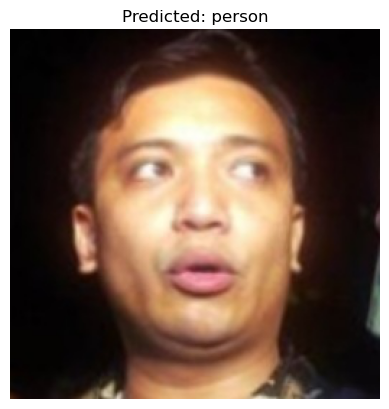

In [26]:
# import matplotlib.pyplot as plt

plt.imshow(image.load_img(img_path))
plt.title(f"Predicted: {predicted_class}")
plt.axis("off")
plt.show()

In [29]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input

def predict_image(img_path):
    # Load image with SAME size as training
    img = image.load_img(img_path, target_size=(224, 224))
    
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    
    # IMPORTANT: use same preprocessing as training
    img_array = preprocess_input(img_array)

    prediction = model.predict(img_array)
    class_index = np.argmax(prediction)
    
    print("Prediction:", class_names[class_index])
    print("Confidence:", np.max(prediction) * 100, "%")

# Example (use image from your 8 classes)
predict_image(r"C:\Users\RASHID\Downloads\archive (3)\_test\flower\flower_0074.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
Prediction: flower
Confidence: 100.0 %
